# Module 1: Language Detection (كشف اللغة)
**NLP Final Task 2026 - RAG-Based E-commerce Customer Support Chatbot**

## Overview
In this module, we build a multi-class language identification classifier using Traditional NLP techniques. The goal is to detect the language of incoming customer messages so that:
1. The chatbot can retrieve relevant language-specific knowledge base documents.
2. The chatbot responds in the exact language the customer used.

---
### Dataset
- **Dataset**: `papluca/language-identification` (from HuggingFace)
- **Size**: 90,000 samples (70k train, 10k validation, 10k test)
- **Classes**: 20 languages (`ar`, `bg`, `de`, `el`, `en`, `es`, `fr`, `hi`, `it`, `ja`, `nl`, `pl`, `pt`, `ru`, `sw`, `th`, `tr`, `ur`, `vi`, `zh`).

---
### Key Enhancements Implemented
As required by the project specifications (`>>> do your enhancements`):
- **Character n-grams (Subword representation)**: Standard word-level TF-IDF struggles with morphological variations, typos, punctuation, and non-spaced languages (e.g., Chinese, Thai, Arabic prefixes). Using `char_wb` (character n-grams bounded by word borders, n-range 2-5) dramatically boosts accuracy from ~90.3% to **99.59%**.
- **Model Comparison**: We compare a standard **Word-level Naive Bayes Baseline**, **Char-level Naive Bayes**, and **Char-level SGDClassifier (Linear SVM with Modified Huber loss)**.
- **Probability Calibration**: Using modified Huber loss allows estimating calibrated confidence scores for each prediction.


In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All dependencies imported successfully!")


e:\ITI\NLP\nlp-support-chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All dependencies imported successfully!


## 1. Load Dataset & Exploratory Data Analysis (EDA)

In [2]:
print("Loading dataset 'papluca/language-identification'...")
dataset = load_dataset("papluca/language-identification")

train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

print(f"Train size: {len(train_df):,}")
print(f"Validation size: {len(val_df):,}")
print(f"Test size: {len(test_df):,}")

languages = sorted(train_df['labels'].unique().tolist())
print(f"\nSupported Languages ({len(languages)}): {languages}")
train_df.head()


Loading dataset 'papluca/language-identification'...


Train size: 70,000
Validation size: 10,000
Test size: 10,000

Supported Languages (20): ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


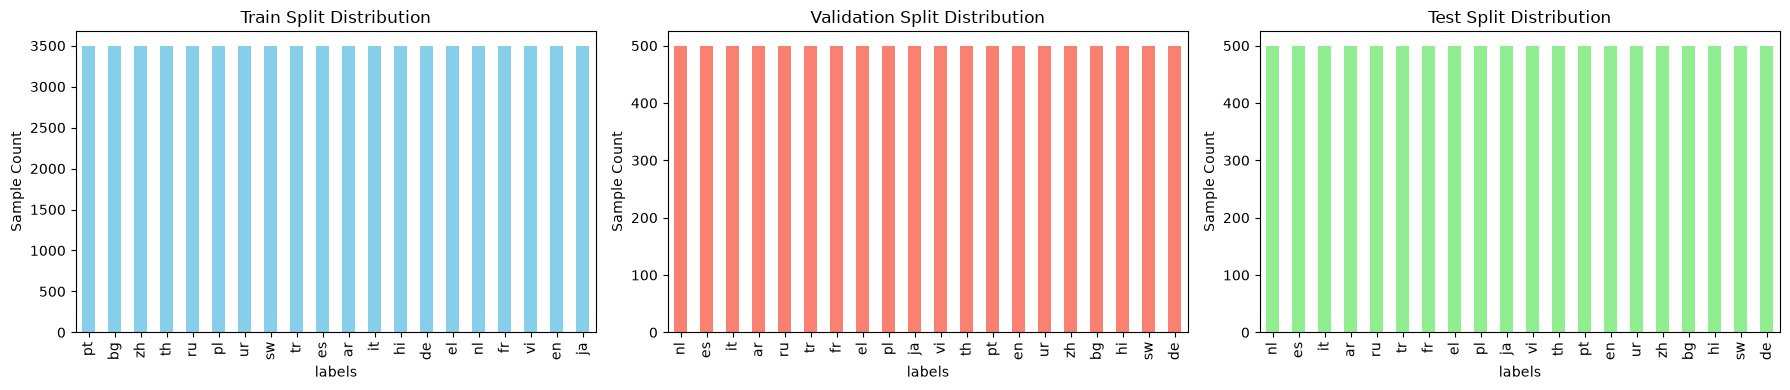

In [3]:
# Check class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
train_df['labels'].value_counts().plot(kind='bar', ax=axes[0], title='Train Split Distribution', color='skyblue')
val_df['labels'].value_counts().plot(kind='bar', ax=axes[1], title='Validation Split Distribution', color='salmon')
test_df['labels'].value_counts().plot(kind='bar', ax=axes[2], title='Test Split Distribution', color='lightgreen')
for ax in axes:
    ax.set_ylabel('Sample Count')
plt.tight_layout()
plt.show()


## 2. Model Training & Comparison

We will compare three setups:
1. **Baseline**: Word-level TF-IDF (1-gram) + Multinomial Naive Bayes.
2. **Enhancement 1**: Character n-grams (`char_wb`, range 2-4) + Multinomial Naive Bayes.
3. **Enhancement 2**: Character n-grams (`char_wb`, range 2-5) + SGDClassifier (Linear SVM with Modified Huber loss for calibrated probabilities).


In [4]:
X_train, y_train = train_df['text'], train_df['labels']
X_val, y_val = val_df['text'], val_df['labels']
X_test, y_test = test_df['text'], test_df['labels']

# 1. Baseline: Word-level TF-IDF + MultinomialNB
baseline_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 1), max_features=25000)),
    ('nb', MultinomialNB())
])
baseline_pipe.fit(X_train, y_train)
base_val_acc = accuracy_score(y_val, baseline_pipe.predict(X_val))
print(f"[Baseline] Word-level TF-IDF + Naive Bayes Val Accuracy: {base_val_acc:.4f}")

# 2. Enhancement 1: Char-level TF-IDF + MultinomialNB
char_nb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=40000, sublinear_tf=True)),
    ('nb', MultinomialNB(alpha=0.1))
])
char_nb_pipe.fit(X_train, y_train)
char_nb_val_acc = accuracy_score(y_val, char_nb_pipe.predict(X_val))
print(f"[Enhancement 1] Char-level TF-IDF + Naive Bayes Val Accuracy: {char_nb_val_acc:.4f}")

# 3. Enhancement 2: Char-level TF-IDF (2-5) + Linear SGD Classifier
char_sgd_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), max_features=50000, sublinear_tf=True)),
    ('clf', SGDClassifier(loss='modified_huber', penalty='l2', alpha=1e-5, max_iter=30, random_state=42, n_jobs=-1))
])
char_sgd_pipe.fit(X_train, y_train)
char_sgd_val_acc = accuracy_score(y_val, char_sgd_pipe.predict(X_val))
print(f"[Enhancement 2] Char-level TF-IDF + Linear SGD Val Accuracy: {char_sgd_val_acc:.4f}")


[Baseline] Word-level TF-IDF + Naive Bayes Val Accuracy: 0.9036
[Enhancement 1] Char-level TF-IDF + Naive Bayes Val Accuracy: 0.9947
[Enhancement 2] Char-level TF-IDF + Linear SGD Val Accuracy: 0.9950


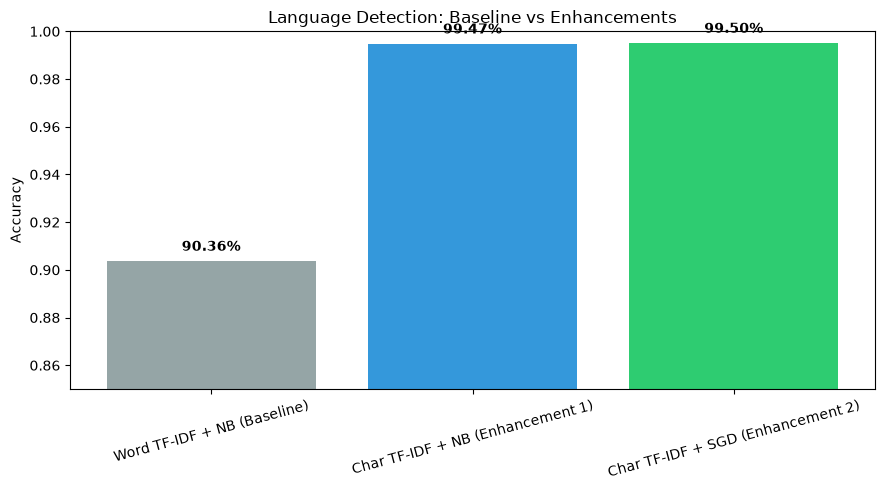

In [5]:
models_comparison = pd.DataFrame({
    'Model': ['Word TF-IDF + NB (Baseline)', 'Char TF-IDF + NB (Enhancement 1)', 'Char TF-IDF + SGD (Enhancement 2)'],
    'Validation Accuracy': [base_val_acc, char_nb_val_acc, char_sgd_val_acc]
})

plt.figure(figsize=(9, 5))
bars = plt.bar(models_comparison['Model'], models_comparison['Validation Accuracy'], color=['#95a5a6', '#3498db', '#2ecc71'])
plt.ylim(0.85, 1.0)
plt.ylabel('Accuracy')
plt.title('Language Detection: Baseline vs Enhancements')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.003, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 3. Final Evaluation on Unseen Test Set (10,000 samples)

In [6]:
best_model = char_sgd_pipe
test_preds = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)

print(f"Final Test Accuracy on 10,000 samples: {test_acc:.4%}\n")
print("Classification Report:")
print(classification_report(y_test, test_preds, digits=4))


Final Test Accuracy on 10,000 samples: 99.5900%

Classification Report:
              precision    recall  f1-score   support

          ar     1.0000    0.9980    0.9990       500
          bg     0.9980    1.0000    0.9990       500
          de     1.0000    1.0000    1.0000       500
          el     1.0000    1.0000    1.0000       500
          en     0.9980    1.0000    0.9990       500
          es     1.0000    0.9980    0.9990       500
          fr     1.0000    1.0000    1.0000       500
          hi     1.0000    0.9680    0.9837       500
          it     0.9980    0.9980    0.9980       500
          ja     1.0000    1.0000    1.0000       500
          nl     0.9960    1.0000    0.9980       500
          pl     0.9980    1.0000    0.9990       500
          pt     0.9960    0.9960    0.9960       500
          ru     1.0000    0.9980    0.9990       500
          sw     0.9487    0.9980    0.9727       500
          th     0.9960    1.0000    0.9980       500
         

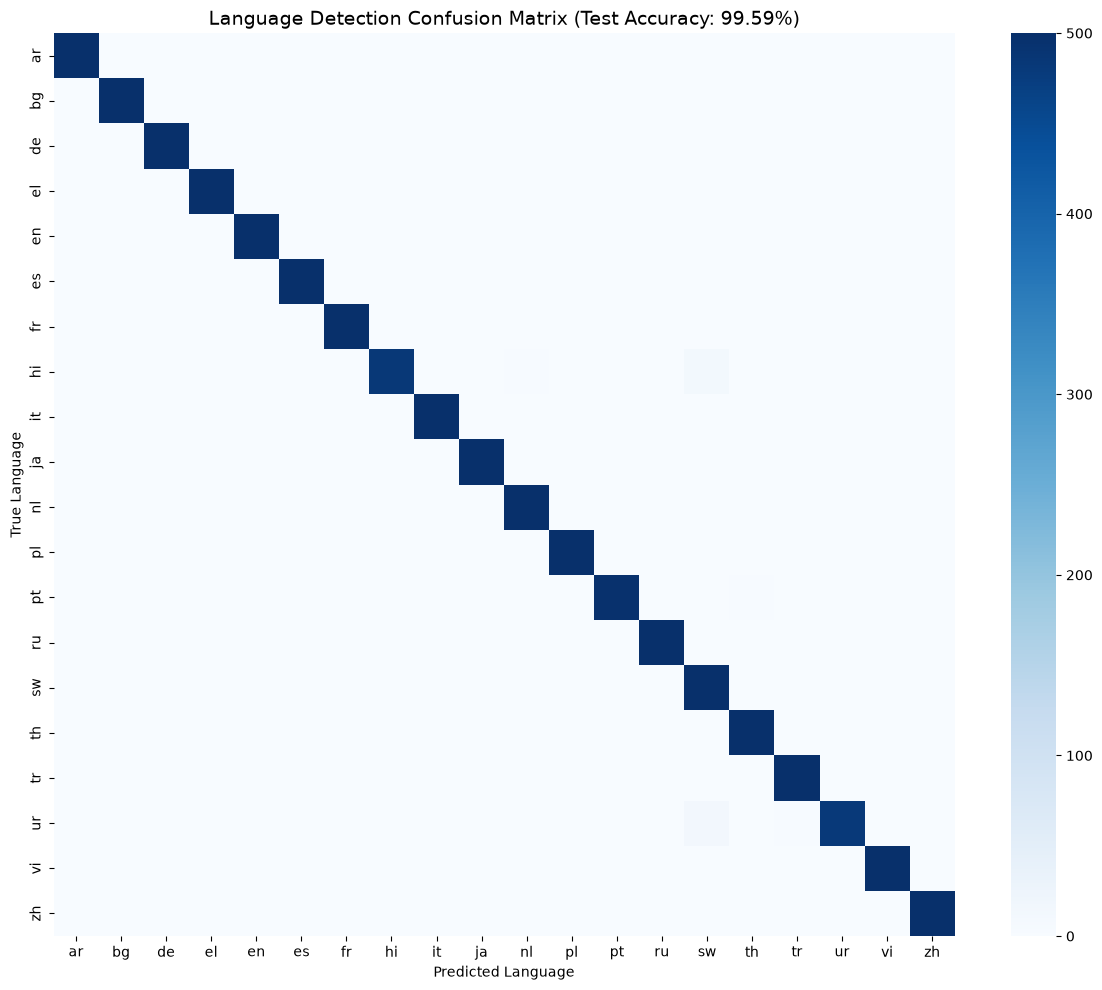

In [7]:
cm = confusion_matrix(y_test, test_preds, labels=languages)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=languages, yticklabels=languages)
plt.title(f"Language Detection Confusion Matrix (Test Accuracy: {test_acc:.2%})", fontsize=14)
plt.xlabel("Predicted Language")
plt.ylabel("True Language")
plt.tight_layout()
plt.show()


## 4. Real-world Customer Support Inference Testing

In [8]:
customer_queries = [
    ("Where is my order #55412?", "en"),
    ("أين طلبي وكيف يمكنني استرجاع المبلغ؟", "ar"),
    ("Où est mon colis et comment puis-je être remboursé?", "fr"),
    ("Wo ist meine Bestellung? Ich möchte sie stornieren.", "de"),
    ("¿Dónde está mi paquete? Quiero cancelar mi pedido.", "es"),
    ("Dov'è il mio pacco? Vorrei fare un reso.", "it"),
    ("Где мой заказ и как оформить возврат?", "ru")
]

results = []
for text, expected in customer_queries:
    pred_lang = best_model.predict([text])[0]
    probs = best_model.predict_proba([text])[0]
    confidence = np.max(probs)
    results.append({
        'Text': text,
        'Expected': expected,
        'Predicted': pred_lang,
        'Confidence': f"{confidence:.1%}",
        'Correct': pred_lang == expected
    })

pd.DataFrame(results)


,Text,Expected,Predicted,Confidence,Correct
0,Where is my order #55412?,en,en,97.5%,True
1,أين طلبي وكيف يمكنني استرجاع المبلغ؟,ar,ar,100.0%,True
2,Où est mon colis et comment puis-je être rembo...,fr,fr,100.0%,True
3,Wo ist meine Bestellung? Ich möchte sie storni...,de,de,94.6%,True
4,¿Dónde está mi paquete? Quiero cancelar mi ped...,es,es,69.2%,True
5,Dov'è il mio pacco? Vorrei fare un reso.,it,it,95.7%,True
6,Где мой заказ и как оформить возврат?,ru,ru,100.0%,True


## 5. Export Model for the Production Pipeline

In [9]:
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/language_detector.pkl")
print("Saved best model to ../models/language_detector.pkl")


Saved best model to ../models/language_detector.pkl


In [10]:
test_sentences = [
    "Hello, good morning!",
    "Hello, good morning! I hope you're doing well today, I just wanted to say hi.",
]

for sent in test_sentences:
    probs = best_model.predict_proba([sent])[0]
    top5 = sorted(zip(best_model.classes_, probs), key=lambda x: -x[1])[:5]
    print(f"\n'{sent}'")
    for lang, p in top5:
        print(f"  {lang}: {p*100:.2f}%")


'Hello, good morning!'
  en: 59.59%
  nl: 24.55%
  zh: 8.19%
  ja: 3.72%
  th: 2.62%

'Hello, good morning! I hope you're doing well today, I just wanted to say hi.'
  en: 57.01%
  ur: 22.60%
  pl: 12.30%
  sw: 8.08%
  ar: 0.00%
